In [1]:
from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


In [2]:
import numpy as np

def precision(y_true, y_pred, normalize=True, sample_weight=None):
    pre_list = []
    for i in range(y_true.shape[0]):
        set_true = set( np.where(y_true[i])[0] )
        set_pred = set( np.where(y_pred[i])[0] )
        tmp_prec = None
        if len(set_true) == 0 and len(set_pred) == 0:
            tmp_prec = 1
            pre_list.append(tmp_prec)
        elif len(set_pred) > 0:
            tmp_prec = len(set_true.intersection(set_pred))/\
                    float(len(set_pred))
            pre_list.append(tmp_prec)
        else:
            None
    return np.mean(pre_list)

def recall(y_true, y_pred, normalize=True, sample_weight=None):
    rec_list = []
    for i in range(y_true.shape[0]):
        set_true = set( np.where(y_true[i])[0] )
        set_pred = set( np.where(y_pred[i])[0] )
        tmp_rec = None
        if len(set_true) == 0 and len(set_pred) == 0:
            tmp_rec = 1
        else:
            tmp_rec = len(set_true.intersection(set_pred))/\
                    float(len(set_true))
        rec_list.append(tmp_rec)
    return np.mean(rec_list)

def f_score(y_true, y_pred, normalize=True, sample_weight=None):
    acc_list = []
    for i in range(y_true.shape[0]):
        set_true = set( np.where(y_true[i])[0] )
        set_pred = set( np.where(y_pred[i])[0] )
        tmp_a = None
        if len(set_true) == 0 and len(set_pred) == 0:
            tmp_a = 1
        else:
            tmp_a = (2*len(set_true.intersection(set_pred)))/\
                    float( len(set_true) + len(set_pred))
        acc_list.append(tmp_a)
    return np.mean(acc_list)

In [3]:
import math
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import load_model
from keras import backend as K
from keras.preprocessing import sequence
from keras.models import Sequential
from keras.layers import Dense
from sklearn.model_selection import train_test_split
import keras
tf.random.set_seed(7)

In [4]:
from csv import writer

def test_segment(filename, low, up):
    myFile = open(filename, 'w', newline = '')
    with myFile:
        csv_writer = writer(myFile)
        for j, row in enumerate(seqData):
            segment = [ ]
            if(len(row) > low and len(row) < up):
                segment.append(row)
                for item in label[j]:
                    segment.append(item)
                csv_writer.writerow(segment)
    myFile.close()

dataframe = pd.read_csv("/content/gdrive/My Drive/Transformer_positional_embedding/data2017/bp/testData.csv", header=None)
dataset = dataframe.values
seqData = dataset[:,0]
label = dataset[:,1:len(dataset[0])]
print('Original Dataset Size : %s' %len(dataset))
test_segment('testData200.csv', 0, 201)
test_segment('testData500.csv', 200, 501)
test_segment('testData1000.csv', 500, 1001)
test_segment('testData16000.csv', 1000, 16000)

Original Dataset Size : 3359


In [5]:
def segment(dataset, label, seg_size, overlap):
    print("Non-overlapping Region: %s" %overlap)
    print("Segment Size: %s" %seg_size)

    seq_data, label_data = [], []
    for j, row in enumerate(dataset):
        if(len(row) < 2001):
            pos = math.ceil(len(row)/overlap)
            if(pos < math.ceil(seg_size/overlap)):
                pos = math.ceil(seg_size/overlap)
            for itr in range(pos - math.ceil(seg_size/overlap) + 1):
                init = itr * overlap
                if(len(row[init : init + seg_size]) > 40):
                    seq_data.append(row[init : init + seg_size])
                    label_data.append(label[j])
    return seq_data, label_data

dataframe = pd.read_csv('/content/gdrive/My Drive/Transformer_positional_embedding/data2017/bp/trainData.csv', header=None)
dataset = dataframe.values
print('Original Dataset Size : %s' %len(dataset))
X = dataset[:,0]
Y = dataset[:,1:len(dataset[0])]
del dataframe, dataset
print(X.shape, Y.shape)

# Preparing For Training
segmentSize = 200
nonOL = segmentSize - 50
SEG = str(segmentSize)

X, Y = segment(X, Y, segmentSize, nonOL)
nb_of_cls = len(Y[0])

#Split the dataset
x_tr, x_val, y_tr, y_val = train_test_split(X, Y, test_size = 0.1, random_state = 42)
del X, Y

y_train = np.array(y_tr, dtype=None)
y_validate = np.array(y_val, dtype=None)
print(len(x_tr), len(x_val))
print(y_train.shape, y_validate.shape)

del y_tr, y_val

Original Dataset Size : 43457
(43457,) (43457, 295)
Non-overlapping Region: 150
Segment Size: 200
105584 11732
(105584, 295) (11732, 295)


In [6]:
def dictionary(chunk_size):
    dataframe = pd.read_csv("/content/gdrive/My Drive/Transformer_positional_embedding/data2017/bp/trainData.csv", header=None)
    dataset = dataframe.values
    del dataframe

    seq_dataset = dataset[:,0]
    print('Creating Dictionary:')
    dict = {}
    j = 0
    for row in seq_dataset:
        for i in range(len(row) - chunk_size + 1):
            key = row[i:i + chunk_size]
            if key not in dict:
                dict[key] = j
                j = j + 1
    del dataset, seq_dataset
    return(dict)

def nGram(dataset, chunk_size, dictI):
    dict1 = list()
    for j, row in enumerate(dataset):
        string = row
        dict2 = list()
        for i in range(len(string) - chunk_size + 1):
            try:
                dict2.append(dictI[string[i:i + chunk_size]])
            except:
                None
        dict1.append(dict2)
    return(dict1)

# CREATING DICTIONARY
chunkSize = 4
dict_Prop = dictionary(chunkSize)
max_seq_len = segmentSize - chunkSize + 1

Creating Dictionary:


In [7]:
def DC_CNN_Block(nb_filter, filter_length, dilation, l2_layer_reg):
    def f(input_):
        residual = input_
        layer_out = layers.Conv1D(filters=nb_filter, kernel_size=filter_length, dilation_rate=dilation,
                                  activation='linear', padding='same', use_bias=True) (input_)
        layer_out = layers.BatchNormalization(epsilon=1.1e-5)(layer_out)
        layer_out = layers.LeakyReLU(alpha = 0.2)(layer_out)

        # compute importance for each step
        attention1 = layers.Dense(1, activation='tanh')(layer_out)
        attention1 = layers.Flatten()(attention1)
        attention1 = layers.Activation('softmax')(attention1)

        attention2 = layers.Dense(1, activation='tanh')(layer_out)
        attention2 = layers.Flatten()(attention2)
        attention2 = layers.Activation('softmax')(attention2)

        attention3 = layers.Dense(1, activation='tanh')(layer_out)
        attention3 = layers.Flatten()(attention3)
        attention3 = layers.Activation('softmax')(attention3)

        attention = layers.Add()([attention1,attention2,attention3])
        attention = layers.RepeatVector(nb_filter)(attention)
        attention = layers.Permute([2, 1])(attention)

        sent_representation = layers.Multiply()([layer_out, attention])
        #sent_representation = layers.GlobalAveragePooling1D()(sent_representation)
        sent_representation = layers.Lambda(lambda xin: keras.ops.sum(xin, axis=1))(sent_representation)
        return sent_representation
    return f

embed_dim = 64
ff_dim = 960

def DC_CNN_Model(top_words, seq_len, o_dim):
    f_num = 192
    f_size = [6,6,6,6,6]

    _input = layers.Input(shape=(seq_len,))
    emd = layers.Embedding(top_words, embed_dim, input_length = seq_len)(_input)
    drop1 = layers.Dropout(0.3)(emd)

    l1 = DC_CNN_Block(f_num, f_size[0], 1, 0.001)(drop1)
    l2 = DC_CNN_Block(f_num, f_size[1], 3, 0.001)(drop1)
    l3 = DC_CNN_Block(f_num, f_size[2], 5, 0.001)(drop1)
    l4 = DC_CNN_Block(f_num, f_size[3], 7, 0.001)(drop1)
    l5 = DC_CNN_Block(f_num, f_size[4], 9, 0.001)(drop1)

    x = layers.Concatenate(axis = -1)([l1, l2, l3, l4, l5])

    x = layers.Dropout(0.4)(x)
    _output = layers.Dense(o_dim, kernel_initializer='normal', activation='sigmoid', name='CLASSIFIER')(x)

    model = keras.Model(inputs=_input, outputs=_output)
    model.compile(loss = tf.keras.losses.BinaryCrossentropy(),
                  optimizer = tf.keras.optimizers.Adam(learning_rate=0.0005),
                  metrics = [tf.keras.metrics.BinaryAccuracy(threshold=0.5)])
    return model

#CREATING N-GRAM
x_train = nGram(x_tr, chunkSize, dict_Prop)
x_validate = nGram(x_val, chunkSize, dict_Prop)
#del x_tr, x_val

# truncate and pad input sequences
x_train = sequence.pad_sequences(x_train, maxlen=max_seq_len)
x_validate = sequence.pad_sequences(x_validate, maxlen=max_seq_len)

# Create & Compile the model
model = DC_CNN_Model(len(dict_Prop), max_seq_len, nb_of_cls)
print(model.summary())

/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)  │ (None, 197)            │              0 │ -                      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ embedding (Embedding)     │ (None, 197, 64)        │     10,252,800 │ input_layer[0][0]      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout (Dropout)         │ (None, 197, 64)        │              0 │ embedding[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1d (Conv1D)           │ (None, 197, 192)       │         73,920 │ dropout[0][0]          │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1d_1 (Conv1D)         │ (None, 197, 192)       │         73,920 │ dropout[0][0]          │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1d_2 (Conv1D)         │ (None, 197, 192)       │         73,920 │ dropout[0][0]          │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1d_3 (Conv1D)         │ (None, 197, 192)       │         73,920 │ dropout[0][0]          │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1d_4 (Conv1D)         │ (None, 197, 192)       │         73,920 │ dropout[0][0]          │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization       │ (None, 197, 192)       │            768 │ conv1d[0][0]           │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_1     │ (None, 197, 192)       │            768 │ conv1d_1[0][0]         │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_2     │ (None, 197, 192)       │            768 │ conv1d_2[0][0]         │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_3     │ (None, 197, 192)       │            768 │ conv1d_3[0][0]         │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_4     │ (None, 197, 192)       │            768 │ conv1d_4[0][0]         │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ leaky_re_lu (LeakyReLU)   │ (None, 197, 192)       │              0 │ batch_normalization[0… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ leaky_re_lu_1 (LeakyReLU) │ (None, 197, 192)       │              0 │ batch_normalization_1… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ leaky_re_lu_2 (LeakyReLU) │ (None, 197, 192)       │              0 │ batch_normalization_2… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ leaky_re_lu_3 (LeakyReLU) │ (None, 197, 192)       │              0 │ batch_normalization_3… │
├──────────────────────

 Total params: 10,912,630 (41.63 MB)

 Trainable params: 10,910,710 (41.62 MB)

 Non-trainable params: 1,920 (7.50 KB)

None


In [8]:
# Train
early_stopping_monitor1 = keras.callbacks.EarlyStopping(monitor = 'val_loss', patience = 5, verbose = 1)
history = model.fit(x_train, y_train.astype(None),
          validation_data = (x_validate, y_validate.astype(None)),
          epochs = 1000,
          batch_size = 150,
          callbacks=[early_stopping_monitor1],
          verbose=1)

del y_train, y_validate

Epoch 1/1000
704/704 ━━━━━━━━━━━━━━━━━━━━ 97s 94ms/step - binary_accuracy: 0.9771 - loss: 0.0766 - val_binary_accuracy: 0.9938 - val_loss: 0.0437
Epoch 2/1000
704/704 ━━━━━━━━━━━━━━━━━━━━ 87s 48ms/step - binary_accuracy: 0.9939 - loss: 0.0309 - val_binary_accuracy: 0.9946 - val_loss: 0.0249
Epoch 3/1000
704/704 ━━━━━━━━━━━━━━━━━━━━ 41s 48ms/step - binary_accuracy: 0.9950 - loss: 0.0199 - val_binary_accuracy: 0.9952 - val_loss: 0.0206
Epoch 4/1000
704/704 ━━━━━━━━━━━━━━━━━━━━ 41s 48ms/step - binary_accuracy: 0.9963 - loss: 0.0126 - val_binary_accuracy: 0.9955 - val_loss: 0.0189
Epoch 5/1000
704/704 ━━━━━━━━━━━━━━━━━━━━ 41s 48ms/step - binary_accuracy: 0.9973 - loss: 0.0086 - val_binary_accuracy: 0.9956 - val_loss: 0.0187
Epoch 6/1000
704/704 ━━━━━━━━━━━━━━━━━━━━ 41s 48ms/step - binary_accuracy: 0.9979 - loss: 0.0063 - val_binary_accuracy: 0.9957 - val_loss: 0.0188
Epoch 7/1000
704/704 ━━━━━━━━━━━━━━━━━━━━ 41s 48ms/step - binary_accuracy: 0.9983 - loss: 0.0051 - val_binary_accuracy: 0.99

In [9]:
from keras.models import load_model

def cls_predict(pred, normalize=True, sample_weight=None):
    s_mean = np.mean(pred, axis=0)
    #m = max(s_mean)
    #s_mean = (s_mean/m)
    return(list(s_mean))

def final_model(filename):
    print('Extracting features based on LSTM model...... ')
    dataframe2 = pd.read_csv(filename, header=None)
    dataset2 = dataframe2.values
    overlap = 50
    X_test = dataset2[:,0]
    Y_test = dataset2[:,1:len(dataset2[0])]
    c_p = []
    for tag, row in enumerate(X_test):
        pos = math.ceil(len(row) / overlap)
        if(pos < math.ceil(segmentSize/ overlap)):
            pos = math.ceil(segmentSize/ overlap)
        segment = [ ]
        for itr in range(pos - math.ceil(segmentSize/overlap) + 1):
            init = itr * overlap
            segment.append(row[init : init + segmentSize])
        seg_nGram = nGram(segment, chunkSize, dict_Prop)
        test_seg = sequence.pad_sequences(seg_nGram, maxlen=max_seq_len)
        preds = model.predict(test_seg, verbose = 0)
        c_p.append(cls_predict(preds))
    c_p = np.array(c_p)
    return c_p, Y_test

def create_nn_model(dim):
    n_model = Sequential()
    n_model.add(Dense(dim, input_dim = dim, kernel_initializer='normal', activation='relu'))
    n_model.add(Dense(dim, kernel_initializer='normal', activation='sigmoid'))
    n_model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['binary_accuracy'])
    return n_model

# Creates a HDF5 file 'my_model.h5'#
#model_path = '/content/gdrive/My Drive/Transformer_positional_embedding/data2017/bp/Hierarchical MCWS/MCWS/1.64.model_'+str(nonOL)+'_'+ SEG +'.keras'
#model.save(model_path)
#del model
#model = load_model(model_path, custom_objects={'categorical_crossentropy': categorical_crossentropy})

# Training
#X_train_new, Y_train_new = final_model("/content/gdrive/My Drive/Transformer_positional_embedding/data2017/bp/trainData.csv")

# Training model 2
#model1 = create_nn_model(Y_train_new[0].shape[0])
#print(model1.summary())
#early_stopping_monitor = keras.callbacks.EarlyStopping(monitor = 'val_loss', patience = 5, verbose = 1)
#model1.fit(X_train_new, Y_train_new.astype(None),
#           callbacks = [early_stopping_monitor],
#           validation_split = 0.1,
#           epochs = 1000,
#           batch_size = 150,
#           verbose = True)

In [10]:
#pip install 'h5py==2.10.0' --force-reinstall

Extracting features based on LSTM model...... 
(3359, 295) (3359, 295)
THRESHOLD IS =====>  0.01
Recall: 57.45863403574032      Precision: 17.843422862725497      F1-score1: 27.2305630534561       F1-score2: 24.015571924997936
THRESHOLD IS =====>  0.02
Recall: 53.41230277446412      Precision: 29.769498350735656      F1-score1: 38.23089757241859       F1-score2: 31.85216666282143
THRESHOLD IS =====>  0.03
Recall: 50.74965795343884      Precision: 38.463641412077685      F1-score1: 43.76066481543396       F1-score2: 35.30135791757424
THRESHOLD IS =====>  0.04
Recall: 49.218401756359484      Precision: 45.34912954250376      F1-score1: 47.204609160627854       F1-score2: 37.318222483990226
THRESHOLD IS =====>  0.05
Recall: 48.19948443273837      Precision: 51.0361676617932      F1-score1: 49.57728229322094       F1-score2: 38.74018524666813
THRESHOLD IS =====>  0.06
Recall: 47.18151113879009      Precision: 55.46665179539693      F1-score1: 50.98971817340373       F1-score2: 39.539810065

/usr/local/lib/python3.10/dist-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/usr/local/lib/python3.10/dist-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


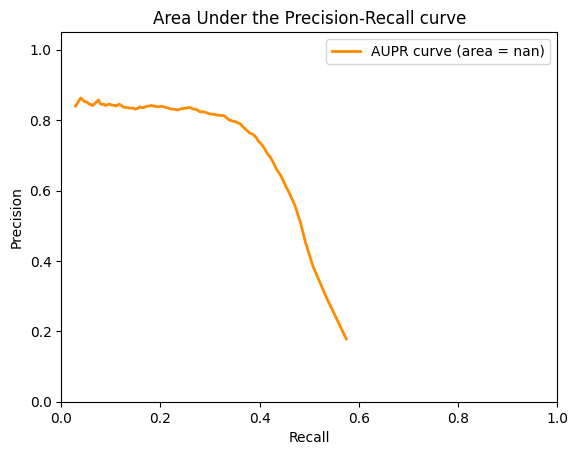

In [11]:
from matplotlib import pyplot as plt

# Testing
def test_fun(file):
    X_test_new, Y_test_new = final_model(file)
    print(X_test_new.shape, Y_test_new.shape)
    Y_test_new = np.array(Y_test_new).astype(None)

    fmax, tmax = 0.0, 0.0
    precisions, recalls = [], []
    for t in range(1, 101, 1):
        #test_preds = model1.predict(X_test_new)
        test_preds = np.copy(X_test_new)

        threshold = t / 100.0
        print("THRESHOLD IS =====> ", threshold)
        test_preds[test_preds>=threshold] = int(1)
        test_preds[test_preds<threshold] = int(0)

        rec = recall(Y_test_new, test_preds)
        pre = precision(Y_test_new, test_preds)
        recalls.append(rec)
        precisions.append(pre)

        f1 = f_score(Y_test_new, test_preds)*100
        f = 2 * pre * rec / (pre + rec)
        print('Recall: {0}'.format(rec*100), '     Precision: {0}'.format(pre*100),
              '     F1-score1: {0}'.format(f*100), '      F1-score2: {0}'.format(f1))

        if fmax < f:
            fmax = f
            tmax = threshold

    precisions = np.array(precisions)
    recalls = np.array(recalls)
    sorted_index = np.argsort(recalls)
    recalls = recalls[sorted_index]
    precisions = precisions[sorted_index]
    aupr = np.trapz(precisions, recalls)
    print(f'AUPR: {aupr:0.3f}')

    plt.figure()
    plt.plot(recalls, precisions, color='darkorange', lw=2, label=f'AUPR curve (area = {aupr:0.2f})')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title('Area Under the Precision-Recall curve')
    plt.legend(loc="upper right")
    plt.savefig(f'aupr.pdf')

    return tmax

th_set = test_fun("/content/gdrive/My Drive/Transformer_positional_embedding/data2017/bp/testData.csv")

In [12]:
# Testing
def test_fun1(file):
    X_test_new, Y_test_new = final_model(file)
    print(X_test_new.shape, Y_test_new.shape)
    test_preds = np.copy(X_test_new)
    Y_test_new = np.array(Y_test_new).astype(None)
    test_preds[test_preds>=th_set] = int(1)
    test_preds[test_preds<th_set] = int(0)
    rec = recall(Y_test_new, test_preds)*100
    pre = precision(Y_test_new, test_preds)*100
    f1 = f_score(Y_test_new, test_preds)*100
    print('      Recall: {0}'.format(rec),  '       Precision: {0}'.format(pre),  '       F1-score: {0}'.format(f1))

test_fun1("testData200.csv")
test_fun1("testData500.csv")
test_fun1("testData1000.csv")
test_fun1("testData16000.csv")

Extracting features based on LSTM model...... 
(345, 295) (345, 295)
      Recall: 31.99648982257678        Precision: 38.49544451562388        F1-score: 26.59326545138902
Extracting features based on LSTM model...... 
(1383, 295) (1383, 295)
      Recall: 38.91691942668081        Precision: 65.38174486853369        F1-score: 35.02778026435651
Extracting features based on LSTM model...... 
(1132, 295) (1132, 295)
      Recall: 50.596387564143754        Precision: 75.20779574487258        F1-score: 47.19467336249684
Extracting features based on LSTM model...... 
(499, 295) (499, 295)
      Recall: 43.23721035143882        Precision: 78.40189118790813        F1-score: 42.22458491963068
